In [1]:
!pip install -q transformers peft torch bitsandbytes datasets accelerate
!pip install -q scikit-learn matplotlib seaborn pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.7 MB/s eta 0:00:00:00:0100:01


In [2]:
import torch, gc, re, json, time, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig,
    TrainingArguments, Trainer, DataCollatorForLanguageModeling,
    GenerationConfig,
)
from peft import (
    LoraConfig, get_peft_model, TaskType,
    prepare_model_for_kbit_training, PeftModel,
)
from datasets import Dataset as HFDataset
warnings.filterwarnings('ignore')

print(f"PyTorch: {torch.__version__}")
print(f"CUDA: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f"GPU: {gpu.name}")
    print(f"VRAM: {gpu.total_memory / 1e9:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA: True
GPU: Tesla T4
VRAM: 15.6 GB


In [3]:
MODEL_ID = "mistralai/Mistral-7B-Instruct-v0.1"

bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.float16,
    bnb_8bit_use_double_quant=True,
    bnb_8bit_quant_type="nf4",
)

print(f"Loading tokenizer: {MODEL_ID}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token    = tokenizer.eos_token
tokenizer.padding_side = "right"

print("Loading model")
t0 = time.time()
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)
model_load_time = time.time() - t0

print(f"Model loaded in {model_load_time:.1f}s")
print(f"Context window : {base_model.config.max_position_embeddings} tokens")
print(f"VRAM allocated : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Loading tokenizer: mistralai/Mistral-7B-Instruct-v0.1


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded in 86.1s
Context window : 32768 tokens
VRAM allocated : 3.32 GB


In [4]:
CONS_PATH = '/kaggle/input/datasets/dianaminnakhmetova/koyash/consultations.csv'
PROD_PATH = '/kaggle/input/datasets/dianaminnakhmetova/koyash/product_catalog.csv'

consultations_df = pd.read_csv(CONS_PATH)
products_df      = pd.read_csv(PROD_PATH).iloc[1:].reset_index(drop=True)

products_df['product_id'] = products_df['product_id'].str.strip()
products_df['name']       = products_df['name'].str.strip()
products_df['price_rub']  = pd.to_numeric(
    products_df['price_rub'].astype(str)
    .str.replace(r'[^\d.]', '', regex=True), errors='coerce'
)

product_dict = {}
for _, r in products_df.iterrows():
    product_dict[r['product_id']] = {
        'name'     : str(r['name']),
        'brand'    : str(r.get('brand', '')),
        'price_rub': r['price_rub'],
        'category' : str(r.get('category', '')),
        'allergens': str(r.get('allergens', '')),
        'issues'   : str(r.get('issues', '')),
    }
VALID_IDS = set(product_dict.keys())

def parse_product_list(s):
    if pd.isna(s): return []
    return [p.strip() for p in str(s).split(',') if p.strip()]

consultations_df['products_list'] = consultations_df['products_recommended'].apply(parse_product_list)
consultations_df['allergies'] = consultations_df['allergies'].fillna('None')

BUDGET_MAP = {
    'low': 5000, 'medium': 10000, 'high': 20000,
    'бюджетный': 5000, 'средний': 10000, 'высокий': 20000,
}
def budget_to_int(b):
    return BUDGET_MAP.get(str(b).strip().lower(), 10000)

consultations_df['budget_int'] = consultations_df['budget'].apply(budget_to_int)

print(f"Consultations:{len(consultations_df)} rows")
print(f"Products: {len(product_dict)} items")
print(f"\n── Budget distribution ──")
print(consultations_df['budget'].value_counts())
print(f"\n── Allergies sample ──")
print(consultations_df['allergies'].value_counts().head())
print(f"\n── Sample products_list ──")
print(consultations_df['products_list'].head(3))
print(f"\n── reasoning length (chars) ──")
consultations_df['_reason_len'] = consultations_df['reasoning'].str.len()
print(consultations_df['_reason_len'].describe())

Consultations:55 rows
Products: 69 items

── Budget distribution ──
budget
medium    25
high      17
low       13
Name: count, dtype: int64

── Allergies sample ──
allergies
None                         41
Propylene Glycol              1
Salicylic Acid, Fragrance     1
Paraben, Fragrance            1
Alcohol, SLS                  1
Name: count, dtype: int64

── Sample products_list ──
0    [product_007, product_027, product_028, produc...
1    [product_018, product_015, product_035, produc...
2    [product_050, product_048, product_045, produc...
Name: products_list, dtype: object

── reasoning length (chars) ──
count     55.000000
mean     382.254545
std       79.819523
min      178.000000
25%      328.000000
50%      397.000000
75%      437.500000
max      536.000000
Name: _reason_len, dtype: float64


In [5]:
def build_training_text(row):
    recommended = "\n".join([
        f"- {product_dict[pid]['name']} ({product_dict[pid]['price_rub']} RUB)"
        for pid in row['products_list'] if pid in product_dict
    ])
    prompt = (
        f"[INST] You are a professional cosmetologist AI.\n"
        f"Client profile:\n"
        f"Age: {row['age']}\n"
        f"Skin type: {row['skin_type']}\n"
        f"Concerns: {row['concerns']}\n"
        f"Budget: {row['budget_int']} RUB\n"
        f"Allergies: {row['allergies']}\n"
        f"Values: {row['values']}\n"
        f"Experience: {row['experience']}\n\n"
        f"Provide: recommended products, total price, reasoning, warnings.\n"
        f"[/INST]"
    )
    response = (
        f"RECOMMENDED PRODUCTS:\n{recommended}\n\n"
        f"TOTAL PRICE: {row['total_price']} RUB\n\n"
        f"REASONING: {row['reasoning']}\n\n"
        f"WARNINGS: {row['warning_notes']}"
    )
    return prompt + "\n" + response, prompt

lengths = []
for _, row in consultations_df.iterrows():
    full_text, _ = build_training_text(row)
    lengths.append(len(tokenizer.encode(full_text)))

lengths = np.array(lengths)
p95 = int(np.percentile(lengths, 95))
MAX_LEN = min(p95, 2048)

print(f"Token length stats:")
print(f"Min: {lengths.min()}")
print(f"Max: {lengths.max()}")
print(f"Mean: {lengths.mean():.0f}")
print(f"Median : {np.median(lengths):.0f}")
print(f"p95: {p95}")
print(f"\n MAX_LEN = {MAX_LEN}")

Token length stats:
Min: 403
Max: 710
Mean: 550
Median : 548
p95: 658

 MAX_LEN = 658


In [6]:
if 'status' in consultations_df.columns:
    consultations_df = consultations_df[
        consultations_df['status'].astype(str).str.upper() == 'TRUE'
    ].reset_index(drop=True)
    print(f"After status filter: {len(consultations_df)} rows")

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    consultations_df, test_size=0.2, random_state=42
)
train_df = train_df.reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} consultations")
print(f"Test: {len(test_df)}  consultations")

def tokenize_fn(examples):
    out = tokenizer(
        examples['text'],
        truncation=True,
        max_length=MAX_LEN,
        padding="max_length",
    )
    out['labels'] = out['input_ids'].copy()
    return out

train_texts = [build_training_text(row)[0] for _, row in train_df.iterrows()]
train_hf = HFDataset.from_dict({'text': train_texts})
train_tok = train_hf.map(tokenize_fn, batched=True, remove_columns=['text'])

print(f"Dataset tokenized | MAX_LEN={MAX_LEN}")
print(f"Sample keys: {list(train_tok[0].keys())}")

After status filter: 55 rows
Train: 44 consultations
Test: 11  consultations


Map:   0%|          | 0/44 [00:00<?, ? examples/s]

Dataset tokenized | MAX_LEN=658
Sample keys: ['input_ids', 'attention_mask', 'labels']


In [7]:
model_for_lora = prepare_model_for_kbit_training(base_model)

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type=TaskType.CAUSAL_LM,
)
model_for_lora = get_peft_model(model_for_lora, lora_config)

trainable, total = model_for_lora.get_nb_trainable_parameters()
print(f"Trainable params : {trainable:,} ({100*trainable/total:.2f}%)")

training_args = TrainingArguments(
    output_dir = "./lora_ckpt",
    num_train_epochs = 5,
    per_device_train_batch_size = 1,
    gradient_accumulation_steps = 8,
    learning_rate = 2e-4,
    warmup_steps = 10,
    optim = "paged_adamw_8bit",
    gradient_checkpointing= True,
    fp16 = True,
    logging_steps= 5,
    save_steps = 50,
    report_to = [],
)

trainer = Trainer(
    model = model_for_lora,
    args = training_args,
    train_dataset = train_tok,
    data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False),
)

print("Training LoRA… ")
t0 = time.time()
train_result = trainer.train()
lora_train_time = time.time() - t0

print(f"\Training complete")
print(f"Final loss: {train_result.training_loss:.4f}")
print(f"Time: {str(timedelta(seconds=int(lora_train_time)))}")

trainer.model.save_pretrained("./lora_final")
tokenizer.save_pretrained("./lora_final")

Trainable params : 13,631,488 (0.19%)
Training LoRA… 


Step,Training Loss
5,2.318277
10,2.000502
15,1.486269
20,1.180161
25,1.010488
30,0.884503


\Training complete
Final loss: 1.4800
Time: 0:16:32


('./lora_final/tokenizer_config.json',
 './lora_final/chat_template.jinja',
 './lora_final/tokenizer.json')

In [8]:
gc.collect(); torch.cuda.empty_cache()

# Reload base + attach LoRA adapter
base_for_inf = AutoModelForCausalLM.from_pretrained(
    MODEL_ID, quantization_config=bnb_config, device_map="auto"
)
lora_model = PeftModel.from_pretrained(base_for_inf, "./lora_final")
lora_model.eval()


GEN_CFG = GenerationConfig(
    max_new_tokens = 300,
    temperature = 0.7,
    top_p = 0.9,
    do_sample = True,
    repetition_penalty = 1.3,
    pad_token_id = tokenizer.eos_token_id,
)

def generate(model, prompt: str) -> tuple[str, float]:
    inputs = tokenizer(
        prompt, return_tensors="pt",
        truncation=True, max_length=MAX_LEN,
    ).to(model.device)

    t0 = time.time()
    with torch.no_grad():
        out_ids = model.generate(
            inputs["input_ids"],
            generation_config=GEN_CFG,
        )
    elapsed = time.time() - t0

    new_ids  = out_ids[0][inputs["input_ids"].shape[1]:]
    text_out = tokenizer.decode(new_ids, skip_special_tokens=True)
    return text_out.strip(), elapsed

test_prompt = (
    "[INST] You are a professional cosmetologist AI.\n"
    "Client: Age 25, oily skin, acne concerns, budget 5000 RUB.\n"
    "Recommend skincare products.\n[/INST]"
)
sample_out, sample_time = generate(lora_model, test_prompt)
print(f"Generation test ({sample_time:.1f}s):\n{sample_out[:300]}")

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Generation test (76.4s):
RECOMMENDED PRODUCTS:
- Glycolic Acid 10% + BHA (387 RUB)
- Birch juice moisturizing sunscreen SPF 50+ PA++++ (964 RUB)
- Aloe Vera Gel (562 RUB)
- Azadirachtin Oil Control (448 RUB)
- Niacinamide 10% + Zinc 1% (822 RUB)
- Vitamin C serum (PHA), NMF Protection (419 RUB)

TOTAL COST: 2,688 РUB

EXPLA


In [11]:
def make_few_shot_block(n=2):
    block = ""
    for _, row in train_df.head(n).iterrows():
        rec = ", ".join([f"{product_dict[p]['name']} ({product_dict[p]['price_rub']} RUB)" for p in row['products_list'] if p in product_dict])
        block += (
            f"--- EXAMPLE ---\n"
            f"PROFILE: Age {row['age']}, {row['skin_type']}, Concerns: {row['concerns']}, Budget: {row['budget_int']} RUB, Allergies: {row['allergies']}\n"
            f"EXPERT LOGIC: {str(row['full_reasoning'])[:300]}...\n"
            f"RECOMMENDATION:\n"
            f"PRODUCTS: {rec}\n"
            f"TOTAL PRICE: {row['total_price']} RUB\n"
            f"WARNINGS: {str(row['warning_notes'])}\n"
        )
    return block

FEW_SHOT_BLOCK = make_few_shot_block()

def build_prompts(row: pd.Series) -> dict:
    profile = (
        f"Age: {row['age']}, Skin type: {row['skin_type']}, Concerns: {row['concerns']}, "
        f"Budget: {row['budget_int']} RUB, Allergies: {row['allergies']}, Values: {row['values']}"
    )
    
    # Общая часть для экспертного тона
    expert_instruction = (
        "You are a Senior Cosmetologist with a deep understanding of cosmetic chemistry and skin physiology. "
        "Your recommendations must be clinically sound, hypoallergenic, and strictly within the client's budget. "
        "Always cross-reference active ingredients with mentioned allergies."
    )

    return {
        # V1: Zero-shot
        "v1_zero_shot": (
            f"[INST] {expert_instruction}\n\nClient: {profile}\n\n"
            f"Propose a skincare routine. Format:\n"
            f"PRODUCTS: [List with prices]\nTOTAL PRICE: <sum> RUB\nREASONING: <Chemistry-based justification>\nWARNINGS: <Safety/Usage notes>\n[/INST]"
        ),
        
        # V2: Few-shot
        "v2_few_shot": (
            f"[INST] {expert_instruction} Review these clinical examples:\n\n{FEW_SHOT_BLOCK}\n"
            f"Now analyze this new client: {profile}\n\n"
            f"RECOMMENDATION:\n[/INST]"
        ),
        
        # V3: CoT 
        "v3_cot": (
            f"[INST] {expert_instruction}\nClient: {profile}\n\n"
            f"Think step-by-step:\n1. Evaluate skin needs based on age and concerns.\n"
            f"2. Filter catalog products by price and safety (allergies).\n"
            f"3. Check for ingredient conflicts (e.g., don't mix AHA/BHA with retinol).\n"
            f"4. Format the final output: PRODUCTS, TOTAL PRICE, REASONING (deep analysis), WARNINGS.\n[/INST]"
        ),
        
        # V4: Role-based
        "v4_role": (
            f"[INST] You are a board-certified dermatologist. Your reputation depends on client safety. "
            f"Your task is to create a professional routine. "
            f"CLIENT: {profile}\n\n"
            f"Provide a clinical recommendation. Be concise but scientifically rigorous.\n"
            f"PRODUCTS: ...\nTOTAL PRICE: ...\nREASONING: ...\nWARNINGS: ... [/INST]"
        ),
        
        # V5: Structured JSON
        "v5_structured": (
            f"[INST] {expert_instruction} Return ONLY valid JSON (no markdown blocks, no text).\n"
            f"Client profile: {profile}\n"
            f"Schema: {{{{ 'products': [{{ 'name': '...', 'price': 0 }}], 'total_price': 0, 'reasoning': '...', 'warnings': '...' }}}}\n[/INST]"
        ),
    }

In [12]:
METHODS = ['lora', 'v1_zero_shot', 'v2_few_shot', 'v3_cot', 'v4_role', 'v5_structured']
METHOD_LABELS = {
    'lora': 'LoRA Fine-tuned',
    'v1_zero_shot': 'Zero-shot',
    'v2_few_shot': 'Few-shot',
    'v3_cot': 'Chain-of-Thought',
    'v4_role': 'Role-based',
    'v5_structured': 'Structured JSON',
}

predictions = {m: [] for m in METHODS}
inference_times = {m: [] for m in METHODS}

for idx, (_, row) in enumerate(test_df.iterrows()):
    print(f"\n[{idx+1}/{len(test_df)}] {row['skin_type']} | budget={row['budget']}")

    _, lora_prompt = build_training_text(row)
    out, t = generate(lora_model, lora_prompt)
    predictions['lora'].append(out)
    inference_times['lora'].append(t)
    print(f"lora : {t:.1f}s | {out[:80].strip()!r}…")

    prompts = build_prompts(row)
    for method in METHODS[1:]:
        out, t = generate(base_for_inf, prompts[method])
        predictions[method].append(out)
        inference_times[method].append(t)
        print(f"  {method:<18}: {t:.1f}s | {out[:80].strip()!r}…")

print("All predictions done!")


[1/11] Комбинированная + меланодермия (хлоазма) | budget=high
lora : 75.6s | 'RECOMMENDED PRODUCTS:\n- Glycolic Acid Toner (1568 RUB)\n- Niacinamide 10% + Zinc'…
  v1_zero_shot      : 76.2s | 'PRODUCTS:\n- Niacinamide 10% + Zinc 1% Round Lab Cream (1598 RUB)\n- Azeloglicine'…
  v2_few_shot       : 77.6s | '= МУЧЕНИE\n\n## РАЗБОР PRIORITY KEEPING\n[•] Розовая химья (регулярно): ✅ Toljana R'…
  v3_cot            : 75.2s | 'Step 1: evaluate_skin_needs = {\n"age": 44, "skincare_concerns": ["гиперпигментац'…
  v4_role           : 75.5s | 'RECOMMENDATION:\n- Формулировать диагнозы (включая базовый MELAS).\n- Провести кон'…
  v5_structured     : 54.8s | '{\n"products": [],\n"total\\_price": 7531,\n"reasoning": "DEPIГMENTATION = МЕЛАНОВЫЙ'…

[2/11] Нормальная кожа | budget=medium
lora : 75.4s | 'RECOMMENDED PRODUCTS:\n- Glycolic Acid Toner (2468 RUB)\n- Niacinamide 10% + Zinc'…
  v1_zero_shot      : 75.4s | '![Instagram](https://insta.flaticon.com/icons/github/square_24x24/796/796827.png'…
  

In [14]:
_catalog_bigrams  = set()
_catalog_unigrams = set()
for pid, info in product_dict.items():
    words = [w.lower() for w in info['name'].split() if len(w) > 3]
    _catalog_unigrams.update(words)
    for i in range(len(words) - 1):
        _catalog_bigrams.add(f"{words[i]} {words[i+1]}")

KNOWN_BRANDS = {
    'round lab', 'bioderma', 'cosrx', 'birch juice', 'nmf protection',
    'dokdo', 'pleyana', 'maskoholic', 'de_code', 'for me', 'aravia',
    'sensibio', 'hydrabio', 'sebium', 'pigmentbio', 'niacinamide',
    'centella', 'lactic acid', 'vitamin tree', 'vitamin c serum',
}

HALLUCINATED_MARKERS = {
    'морщинный сексуалент', 'био-дебилл', 'мёдный маск для лица',
    'смертум акник', 'скинаятельная', 'кремор лаб', 'cosmo dha',
    'hydra vital', 'luminous hydrating', 'мёртвая дробинка',
    'нутреннее увлажняющее', 'мирный сериал',
}

def metric_name_validity(pred: str) -> float:
    pred_lower = pred.lower()
    for marker in HALLUCINATED_MARKERS:
        if marker in pred_lower:
            return 0.0
    brand_hits  = sum(1 for b in KNOWN_BRANDS if b in pred_lower)
    bigram_hits = sum(1 for bg in _catalog_bigrams if bg in pred_lower)
    if brand_hits >= 2 or bigram_hits >= 3: return 1.0
    if brand_hits >= 1 or bigram_hits >= 1: return 0.75
    return 0.5

def metric_budget(pred: str, budget_int: int) -> float | None:
    patterns = [
        r'TOTAL[:\s]+(\d[\d\s,]*)\s*RUB',
        r'[Tt]otal[:\s]+(\d[\d\s,]*)\s*[Rr]ub',
        r'TOTAL PRICE[:\s]+(\d[\d\s,]*)',
        r'"total_price"\s*:\s*(\d+)', 
        r'total_price["\s:]+(\d+)',
        r'(\d{3,6})\s*RUB',
    ]
    for pat in patterns:
        m = re.search(pat, pred)
        if m:
            try:
                price = int(re.sub(r'[\s,]', '', m.group(1)))
                if price > 100:
                    return 1.0 if price <= budget_int else 0.0
            except ValueError:
                continue
    return None

def metric_safety(pred: str, allergies: str) -> float:
    cleaned = allergies.strip().lower()
    if cleaned in ('none', 'нет', 'nan', ''):
        return 1.0
    allergy_list = [a.strip().lower() for a in allergies.split(',') if a.strip()]
    pred_lower   = pred.lower()
    violations   = sum(1 for a in allergy_list if len(a) > 2 and a in pred_lower)
    return 0.0 if violations > 0 else 1.0

def metric_format(pred: str, method: str) -> float:
    pred_lower = pred.lower()
    if method == 'v5_structured':
        keys = ['"products"', '"total_price"', '"reasoning"', '"warnings"']
        return sum(1 for k in keys if k in pred) / len(keys)
    if method == 'v3_cot':
        sections = ['final recommendation', 'products', 'total', 'reasoning', 'warnings']
        return sum(1 for s in sections if s in pred_lower) / len(sections)
    sections = ['products', 'total', 'reasoning', 'warnings']
    return sum(1 for s in sections if s in pred_lower) / len(sections)

records = []

for method in METHODS:
    validity_vals = []
    budget_vals   = []
    safety_vals   = []
    format_vals   = []
    budget_na     = 0
    validity_half = 0

    for i, (_, row) in enumerate(test_df.iterrows()):
        pred = predictions[method][i]

        nv = metric_name_validity(pred)
        b = metric_budget(pred, row['budget_int'])
        s = metric_safety(pred, row['allergies'])
        f = metric_format(pred, method)

        validity_vals.append(nv)
        if nv == 0.5: validity_half += 1

        budget_vals.append(b if b is not None else 0.5)
        if b is None: budget_na += 1

        safety_vals.append(s)
        format_vals.append(f)

    records.append({
        'Method' : METHOD_LABELS[method],
        'Name Validity': round(np.mean(validity_vals), 3),
        'Budget Adherence': round(np.mean(budget_vals), 3),
        'Safety': round(np.mean(safety_vals), 3),
        'Format Score ': round(np.mean(format_vals), 3),
        'Inference Time (s)' : round(np.mean(inference_times[method]), 1),
        '_budget_na': budget_na,
        '_validity_half': validity_half,
    })

metrics_df = pd.DataFrame(records)
display_df = metrics_df.drop(columns=['_budget_na', '_validity_half'])


print("RESULTS")
print(display_df.to_string(index=False))

print("Metric notes ")
for rec in records:
    print(
        f"{rec['Method']:<22} | "
        f"validity undetermined: {rec['_validity_half']}/{len(test_df)} | "
        f"price not found: {rec['_budget_na']}/{len(test_df)}"
    )
print(f"LoRA training time: {str(timedelta(seconds=int(lora_train_time)))}")

RESULTS
          Method  Name Validity  Budget Adherence  Safety  Format Score   Inference Time (s)
 LoRA Fine-tuned          0.977             0.818     1.0          0.750                75.2
       Zero-shot          0.909             0.955     1.0          0.750                75.3
        Few-shot          0.773             0.636     1.0          0.136                77.2
Chain-of-Thought          0.705             0.909     1.0          0.418                73.6
      Role-based          0.659             0.636     1.0          0.091                75.2
 Structured JSON          0.614             0.545     1.0          0.614                33.4
Metric notes 
LoRA Fine-tuned        | validity undetermined: 0/11 | price not found: 2/11
Zero-shot              | validity undetermined: 2/11 | price not found: 1/11
Few-shot               | validity undetermined: 3/11 | price not found: 8/11
Chain-of-Thought       | validity undetermined: 6/11 | price not found: 2/11
Role-based         

In [21]:
# Принудительное переименование, чтобы 100% избавиться от KeyError
display_df = display_df.rename(columns={
    'Name Validity': 'Name Validity',
    'Budget Adherence': 'Budget Adherence',
    'Safety': 'Safety',
    'Format Score ': 'Format Score', # Если там был пробел
    'Format Score ↑': 'Format Score'  # Если там была стрелочка
})

# Проверь, что колонки называются именно так, как ты ждешь
print(display_df.columns.tolist())

['Method', 'Name Validity', 'Budget Adherence', 'Safety', 'Format Score', 'Inference Time (s)']


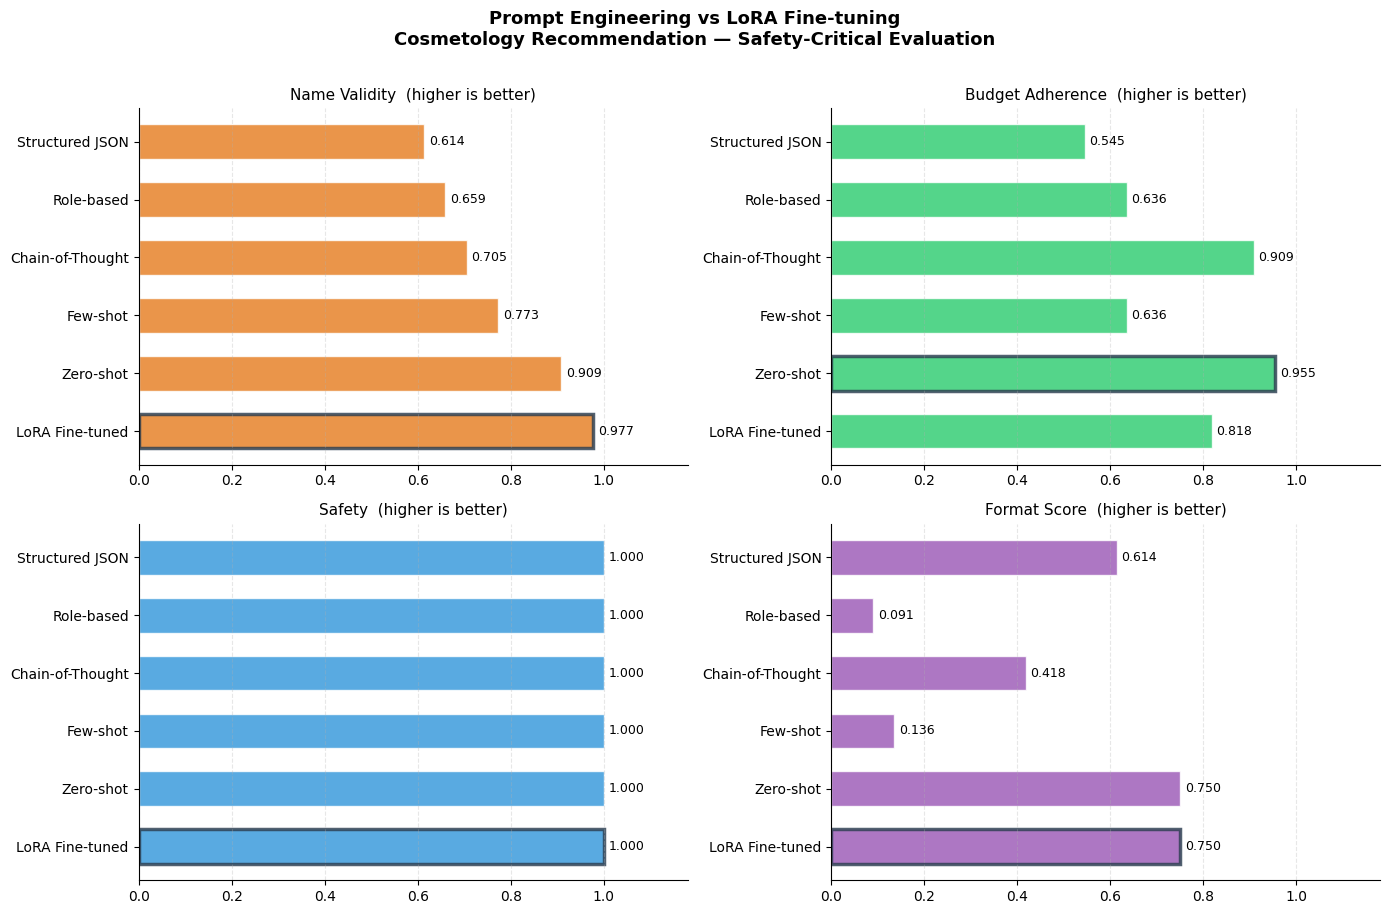

In [22]:
plot_df = display_df.copy()
labels  = plot_df['Method'].tolist()

metrics_to_plot = [
    ('Name Validity','#E67E22', 'higher is better'),
    ('Budget Adherence', '#2ECC71', 'higher is better'),
    ('Safety', '#3498DB', 'higher is better'),
    ('Format Score','#9B59B6', 'higher is better'),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle(
    'Prompt Engineering vs LoRA Fine-tuning\n'
    'Cosmetology Recommendation — Safety-Critical Evaluation',
    fontsize=13, fontweight='bold', y=1.01,
)

for ax, (col, color, note) in zip(axes.flat, metrics_to_plot):
    vals = plot_df[col].tolist()
    bars = ax.barh(labels, vals, color=color, alpha=0.82, edgecolor='white', height=0.6)

    for bar, v in zip(bars, vals):
        ax.text(
            bar.get_width() + 0.01,
            bar.get_y() + bar.get_height() / 2,
            f'{v:.3f}', va='center', fontsize=9,
        )

    ax.set_title(f'{col}  ({note})', fontsize=11)
    ax.set_xlim(0, 1.18)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.spines[['top', 'right']].set_visible(False)

    best_idx = np.argmax(vals)
    bars[best_idx].set_edgecolor('#2C3E50')
    bars[best_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('results_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
lora_row   = display_df[display_df['Method'] == 'LoRA Fine-tuned'].iloc[0]
prompts_df = display_df[display_df['Method'] != 'LoRA Fine-tuned']

best_validity = display_df.loc[display_df['Name Validity'].idxmax(),'Method']
best_safety = display_df.loc[display_df['Safety'].idxmax(),'Method']
best_budget = display_df.loc[display_df['Budget Adherence'].idxmax(), 'Method']
best_format = display_df.loc[display_df['Format Score'].idxmax(), 'Method']

cot_row  = display_df[display_df['Method'] == 'Chain-of-Thought'].iloc[0]
role_row = display_df[display_df['Method'] == 'Role-based'].iloc[0]
few_row  = display_df[display_df['Method'] == 'Few-shot'].iloc[0]
zs_row   = display_df[display_df['Method'] == 'Zero-shot'].iloc[0]

print("=" * 22)
print("FINAL SUMMARY")
print("=" * 22)
print(f"""
BEST PER METRIC
  Name Validity: {best_validity}
  Safety: {best_safety}
  Budget control: {best_budget}
  Format quality: {best_format}

LORA FINE-TUNED — SCORECARD
  Name Validity: {lora_row['Name Validity']:.3f}
  Budget: {lora_row['Budget Adherence']:.3f}
  Safety: {lora_row['Safety']:.3f}
  Format Score: {lora_row['Format Score']:.3f}
  Avg Inference: {lora_row['Inference Time (s)']:.1f}s
  Training cost: {str(timedelta(seconds=int(lora_train_time)))} GPU

PROMPT ENGINEERING — BEST SCORES
  Name Validity: {prompts_df['Name Validity'].max():.3f}  ({prompts_df.loc[prompts_df['Name Validity'].idxmax(), 'Method']})
  Budget: {prompts_df['Budget Adherence'].max():.3f}  ({prompts_df.loc[prompts_df['Budget Adherence'].idxmax(), 'Method']})
  Safety          : {prompts_df['Safety'].max():.3f}  ({prompts_df.loc[prompts_df['Safety'].idxmax(), 'Method']})
  Format Score    : {prompts_df['Format Score'].max():.3f}  ({prompts_df.loc[prompts_df['Format Score'].idxmax(), 'Method']})
  Avg Inference   : {prompts_df['Inference Time (s)'].mean():.1f}s
  Training cost   : 0s
""")

print("=" * 22)
print("QUALITATIVE EXAMPLES")
print("=" * 22)

for case_i in range(min(2, len(test_df))):
    row = test_df.iloc[case_i]
    print(f"\n── Case {case_i + 1} {'─'*50}")
    print(f"Profile : Age {row['age']}, {row['skin_type']}")
    print(f"Concerns : {row['concerns']}")
    print(f"Budget: {row['budget_int']} RUB | Allergies: {row['allergies']}")
    print(f"GT: {str(row['reasoning'])[:200]}")
    print()
    for m in ['lora', 'v1_zero_shot', 'v4_role']:
        pred = predictions[m][case_i]
        nv = metric_name_validity(pred)
        s = metric_safety(pred, row['allergies'])
        f = metric_format(pred, m)
        print(f"[{METHOD_LABELS[m]}]  validity={nv:.2f} safety={s:.2f} format={f:.2f}")
        print(pred[:350])
        print()

display_df.to_csv('final_results.csv', index=False)
with open('experiment_meta.json', 'w') as f:
    json.dump({
        'model' : MODEL_ID,
        'max_len' : MAX_LEN,
        'train_samples': len(train_df),
        'test_samples': len(test_df),
        'lora_r' : 16,
        'lora_alpha' : 32,
        'lora_epochs': 5,
        'lora_train_time_s' : round(lora_train_time, 1),
        'model_load_time_s': round(model_load_time, 1),
        'metrics': display_df.set_index('Method').to_dict(orient='index'),
    }, f, indent=2, ensure_ascii=False)



FINAL SUMMARY

BEST PER METRIC
  Name Validity: LoRA Fine-tuned
  Safety: LoRA Fine-tuned
  Budget control: Zero-shot
  Format quality: LoRA Fine-tuned

LORA FINE-TUNED — SCORECARD
  Name Validity: 0.977
  Budget: 0.818
  Safety: 1.000
  Format Score: 0.750
  Avg Inference: 75.2s
  Training cost: 0:16:32 GPU

PROMPT ENGINEERING — BEST SCORES
  Name Validity: 0.909  (Zero-shot)
  Budget: 0.955  (Zero-shot)
  Safety          : 1.000  (Zero-shot)
  Format Score    : 0.750  (Zero-shot)
  Avg Inference   : 66.9s
  Training cost   : 0s

QUALITATIVE EXAMPLES

── Case 1 ──────────────────────────────────────────────────
Profile : Age 44, Комбинированная + меланодермия (хлоазма)
Concerns : Гиперпигментация на щеках/лбу, хлоазма, неравномерный тон
Budget: 20000 RUB | Allergies: None
GT: МЕЛАНОДЕРМИЯ/ХЛОАЗМА = тяжелая гиперпигментация, часто от солнца + генетика. Нужна АГРЕССИВНАЯ депигментирующая комбинация: COSRX AHA/BHA/C Toner (двойной пилинг). Round Lab Serum (витамин C для освет

[LoRA Fine